In [4]:
import seaborn as sns
from sklearn.datasets import make_blobs


In [5]:
X,y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state = 42
)

<Axes: >

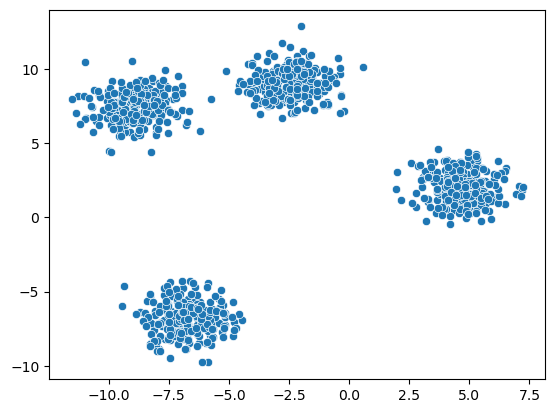

In [7]:
sns.scatterplot(x=X[:,0], y=X[:,1])

In [8]:
# K-Means Clustering
from sklearn.cluster import KMeans

In [10]:
k =4

kmeans = KMeans(
    n_clusters=k,
    random_state=42
)

In [12]:
labels =  kmeans.fit_predict(X)

C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


<Axes: >

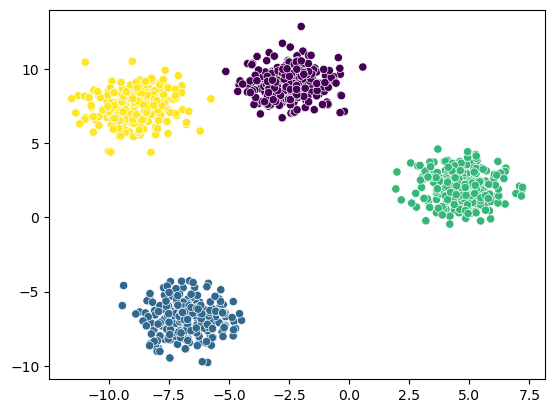

In [13]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], c=labels)

### Choose our K value - elbow; silhouette score

In [14]:
# Elbow Method

wcss = []

for k in range(1, 21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    

C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

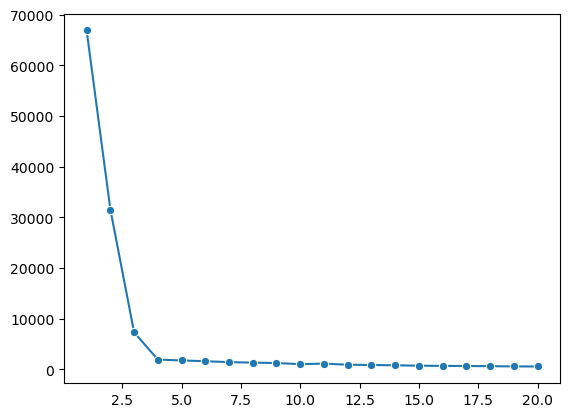

In [15]:
sns.lineplot(x=range(1, 21), y=wcss, marker='o')

In [16]:
# Kneed Module

!pip install kneed

In [17]:
from kneed import KneeLocator

In [18]:
knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing")

print("optimal K = ", knee.elbow)

optimal K =  4


### Silhouette Score

In [19]:
from sklearn.metrics import silhouette_score

In [20]:
ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score =silhouette_score(X, labels)

    ss.append(score)

C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

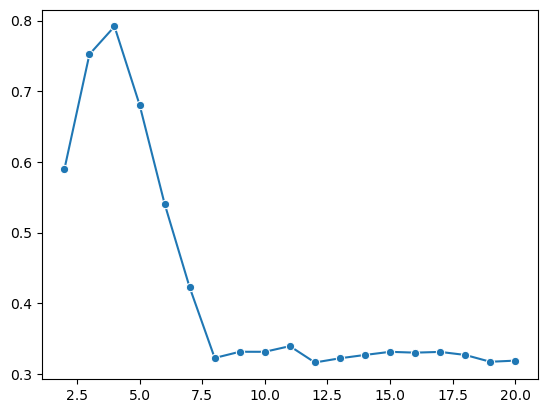

In [21]:
# plot - K & ss

sns.lineplot(x=range(2, 21), y=ss, marker='o')